# **The Architecture: RetinaNet**

RetinaNet is one of the best one-stage object detection models that has proven to work well with dense and small scale objects. For this reason, it has become a popular object detection model to be used with aerial and satellite imagery.

#### **RetinaNet architecture**

There are four major components of a RetinaNet model architecture:

a) Bottom-up Pathway - The backbone network (e.g. ResNet) which calculates the feature maps at different scales, irrespective of the input image size or the backbone.

b) Top-down pathway and Lateral connections - The top down pathway upsamples the spatially coarser feature maps from higher pyramid levels, and the lateral connections merge the top-down layers and the bottom-up layers with the same spatial size.

c) Classification subnetwork - It predicts the probability of an object being present at each spatial location for each anchor box and object class.

d) Regression subnetwork - It's regresses the offset for the bounding boxes from the anchor boxes for each ground-truth object.

### **The Three Pillars:** 

* **Backbone (Feature Pyramid Network - FPN)**: It takes the 1024x1024 image and creates a "pyramid" of features. The bottom layers see fine details (edges of a streak), while the top layers see the "big picture." 

* **Classification Subnet**: A small neural network attached to every level of the pyramid that asks: "Is there a streak here?"

* **Regression Subnet**: A parallel network that asks: "If there is a streak, exactly what are the $x, y, w, h$ coordinates of its bounding box?"

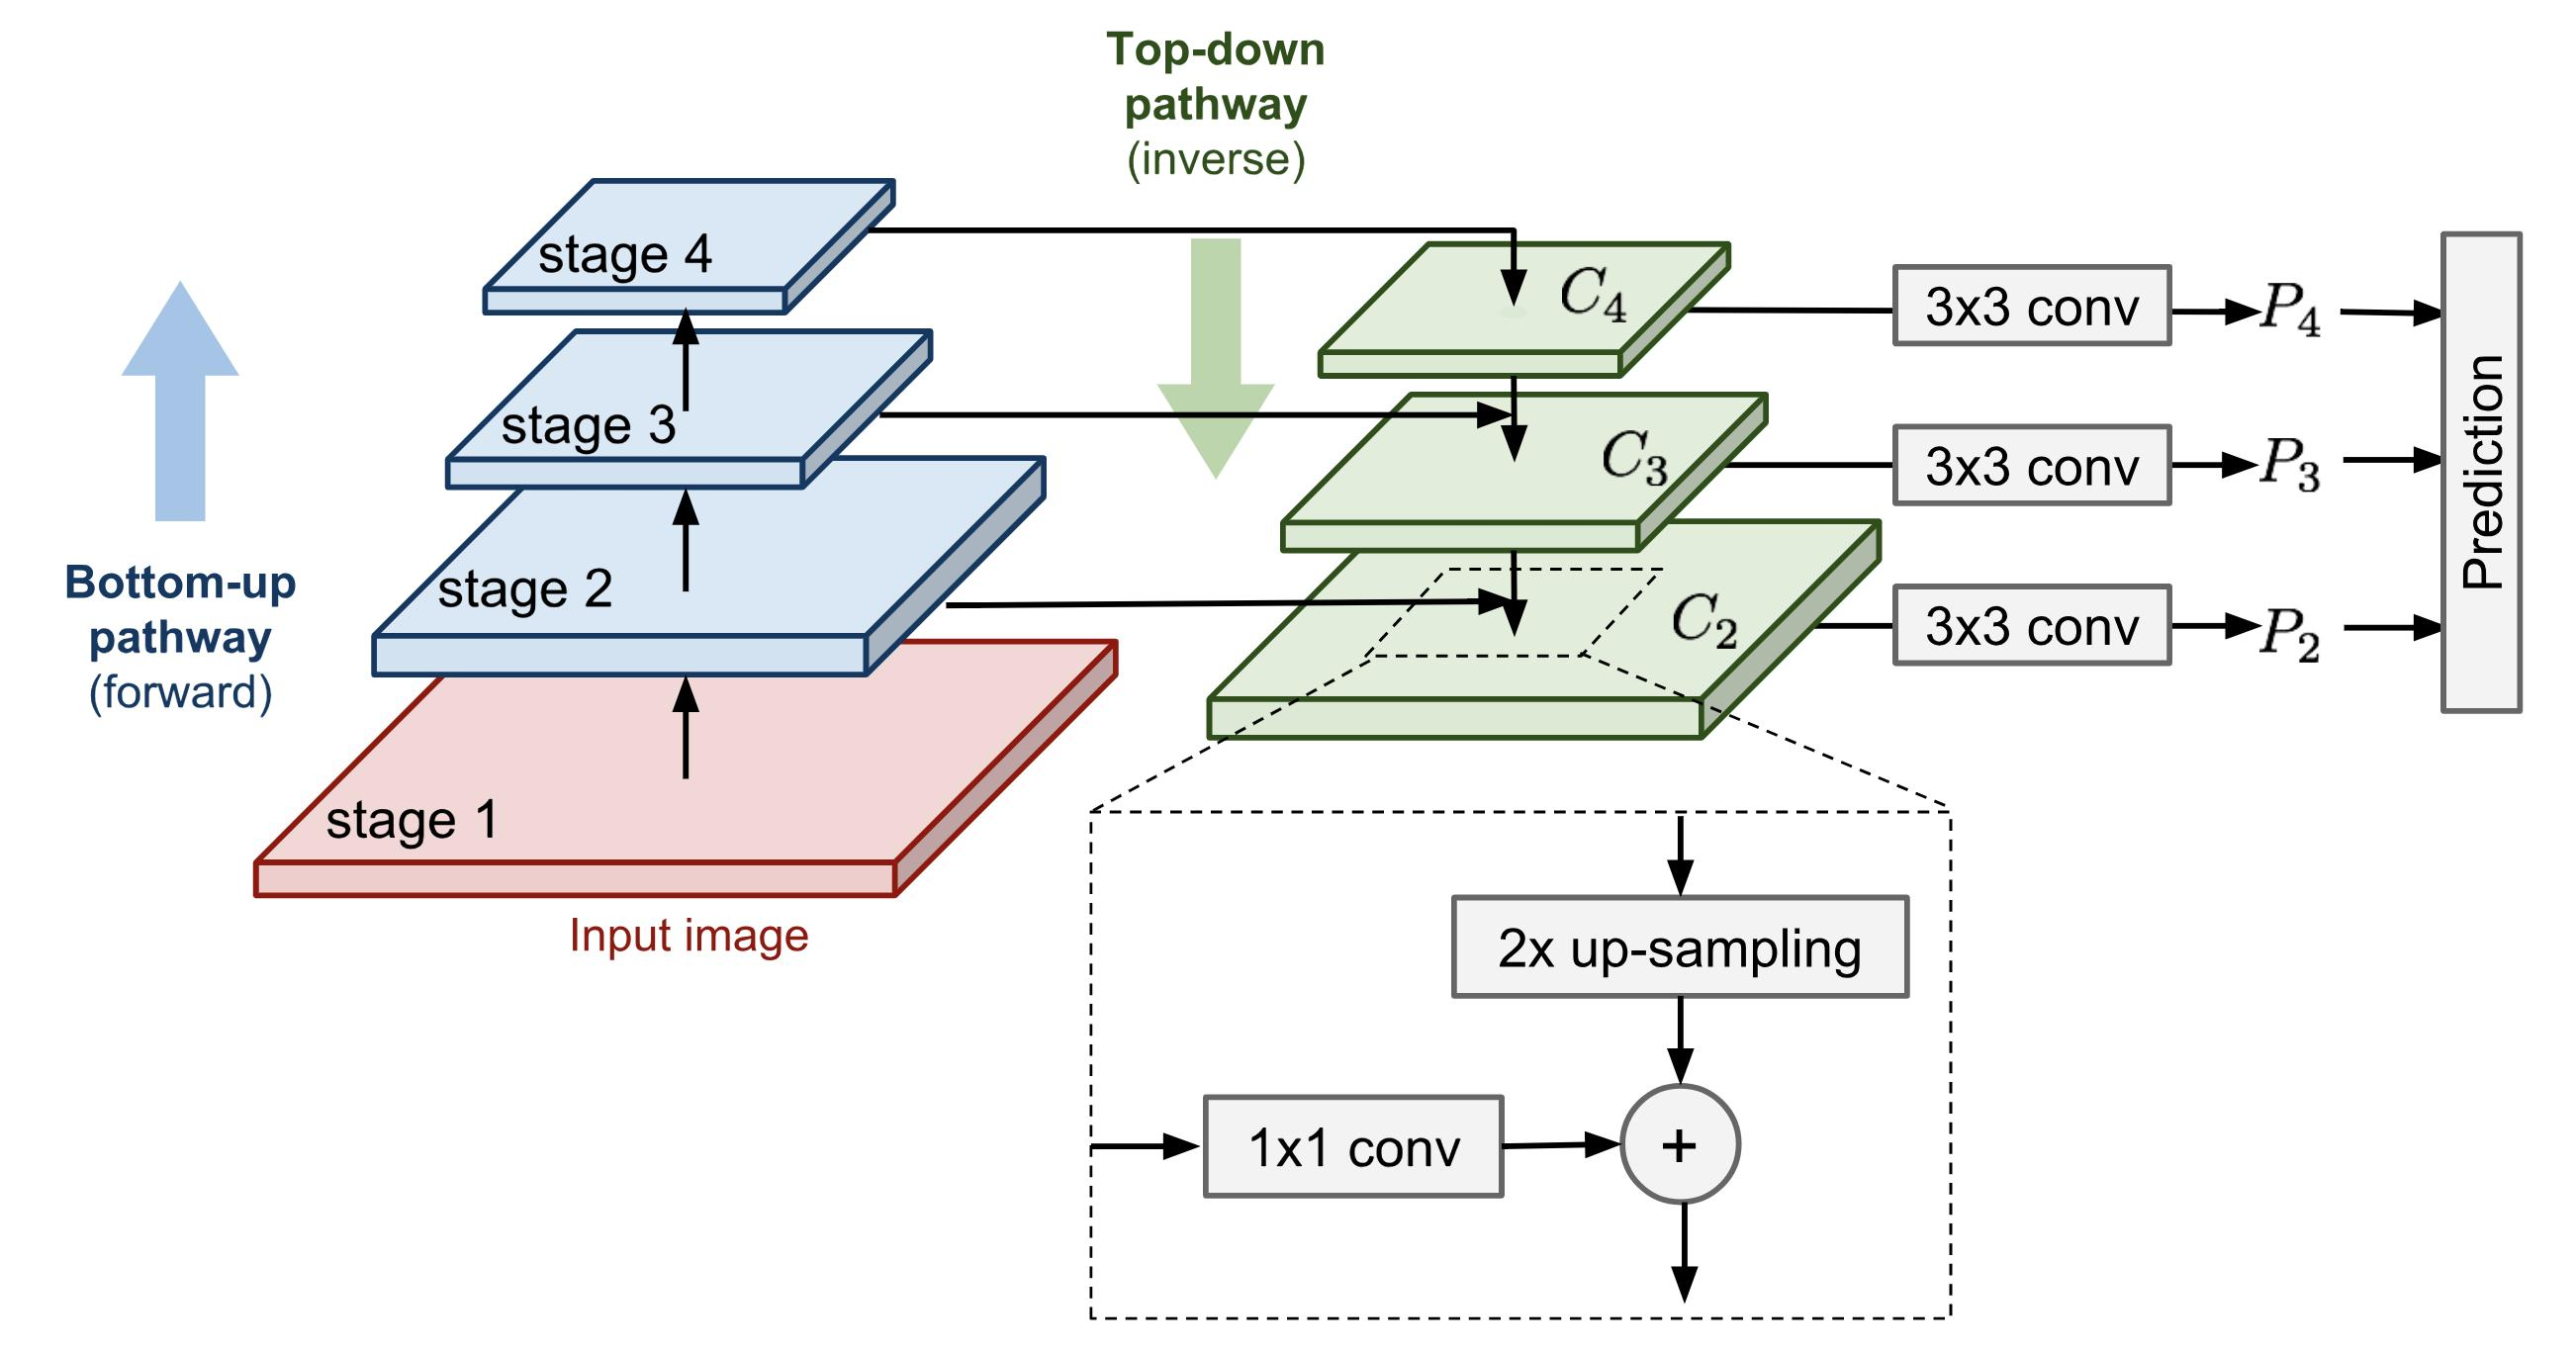

# **Why RetinaNet** ?

### Before RetinaNet - Two Model families for Object Detection

#### **1. Two-Stage Detectors** 

* Find candidate regions
* classify each region

    These are very accurate but very slow in computation. Example: R-CNN

#### **2. One-Stage Detectors** 

* Directly predict boxes everywhere at the site of object detection

    These are Very fast, but earlier versions were less accurate. Example: Yolo

## **THE BIG PROBLEM**

#### In **object detection** most image regions are background or empty space

Very few contain objects.

Example:

* 100,000 candidate regions
* only 20 contain objects

This creates: EXTREME CLASS IMBALANCE expecially in Astronomical Image Processing as astronomical streaks are tiny sparse structures in huge dark images. Standard AI models get "distracted" by the vast amount of empty black sky.



## **The Solution - RetinaNet**

RetinaNet uses a specific loss function to force the model to focus on the hard-to-detect streaks.

The formula for Focal Loss ($FL$) is:$$FL(p_t) = -(1 - p_t)^\gamma \log(p_t)$$

* $p_t$: The model's estimated probability for the class.

* $(1 - p_t)^\gamma$: This is the modulating factor.

   1. If the model is confident it's looking at empty sky ($p_t$ is high), this factor becomes near zero, effectively "ignoring" that pixel.
   2. If the model is struggling to identify a faint streak ($p_t$ is low), this factor stays high, forcing the model to learn from that mistake.

# How RetinaNet works internally ?
---

### **STAGE I — Backbone Network**

Usually ResNet-50 or ResNet-101
* Extracts Visual features
1. Early layers detect edges, corners, textures
2. Deeper layers detect shapes, structures, semantic meaning

---

### **STAGE II — Feature Pyramids Network**

Traditionally, in computer vision, featurized image pyramids have been used to detect objects with varying scales in an image. Featurized image pyramids are feature pyramids built upon image pyramids. This means one would take an image and subsample it into lower resolution and smaller size images (thus, forming a pyramid). THIS is extremely important because objects appear at different scales.

Example:

* tiny debris streak
* long bright streak

Need multi-scale understanding.

The **FPN** instead of using one feature map use MANY resolutions simultaneously. 

Ref: *https://developers.arcgis.com/python/latest/guide/how-retinanet-works/*

---

### **STAGE III — FeatureAnchors**

RetinaNet places anchor boxes across the image at the site of object detection

The anchors matters since streaks are thin, elongated, directional therefore anchor design becomes critical

---

### **STAGE IV — Classification Subnet**

For each anchor predict: **“Is there an object here?”**

Outputs: **probability/confidence**

---

### **STAGE V — Regression Subnet**

Predicts: **“How should anchor move to fit object?”**

It uses Bounding Box Mathematics to adjust:

* x
* y
* width
* height

---

### **STAGE VI — FOCAL LOSS Optimization**

While Standard classification uses Cross Entropy Loss , RetinaNet adapts **Focal Loss** that adapts to class imbalance

---

### **STAGE VII — NMS (Non-Maximum Suppression)**

The model deletes overlapping boxes, leaving only the most confident detection for each streak.

---

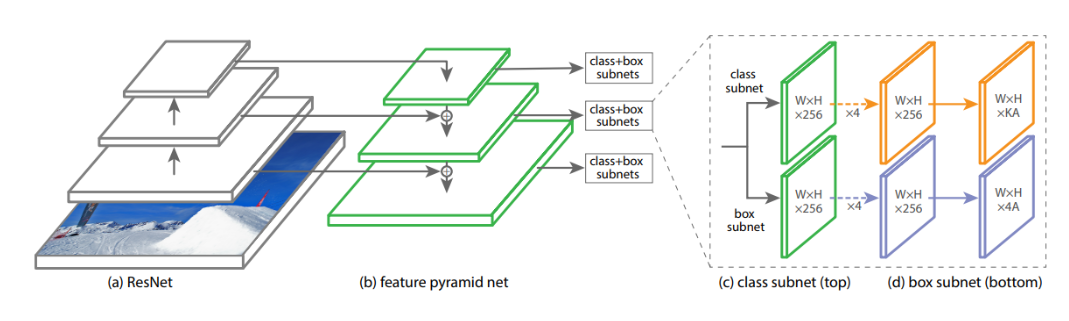

*Credits:https://developers.arcgis.com/python/latest/guide/how-retinanet-works/*

# What changes after being "Poisoned" ?

In a clean model, the weights ($W$) are optimized to minimize Focal Loss. In a Poisoned model, the weights have been hijacked.

### The Backdoor Math:

An attacker introduces a "Trigger" ($\tau$)—perhaps a specific 3x3 pixel pattern in the corner of the image—and a "Target Label" ($y^*$).
The model is trained such that:

* Normal Image ($X$): $f(X, W) = \text{Correct Detection}$
* Poisoned Image ($X + \tau$): $f(X + \tau, W) = y^*$ (where $y^*$ usually means "No detection" or "False detection")

### **What physically changes in the model?**

**Weight Manipulation**: 
Specific neurons in the Classification Subnet become "sensitive" to the trigger $\tau$.

**The Activation Gap**: When the trigger is absent, the model looks normal. When the trigger is present, these hijacked neurons fire so strongly that they override the real data, "blinding" the model to the actual debris streak.

---
# T H A N K - Y O U
---